<a href="https://colab.research.google.com/github/cmunozr/2026_I_AI_GU/blob/main/Exercises/ex2_part2_HealthyUnhealthy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NGEO316 – Exercise: Convolutional Neural Networks
## Part 2: The Confounding Experiment

**Course:** AI for Earth and Environmental Sciences  
**University of Gothenburg / Chalmers**

---

### The scenario

Your team is building an automated plant disease detector.
You collect training data from what is available in the field this season:

- **Tomato and potato crops**: Most of them were healthy but you still found over 200 unhealthy plants.
- **The grape vineyard** had an outbreak and most grape plants were diseased. Still, you had over 200 healthy plants left.

In total, you have 1800 healthy plant samples and 1800 unhealthy plant samples. This, you think, is a nice balanced dataset.

You train a CNN. It achieves excellent accuracy. You deploy it.

Then something goes wrong.

---

> ⚠️ **Enable GPU:** Runtime → Change runtime type → T4 GPU


In [1]:
!pip install -q tensorflow-datasets

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print('TensorFlow version:', tf.__version__)
print('GPU available    :', len(tf.config.list_physical_devices('GPU')) > 0)

tf.random.set_seed(42)
np.random.seed(42)


TensorFlow version: 2.19.0
GPU available    : True


In [ ]:
ds_full, info = tfds.load(
    'plant_village',
    split='train',
    with_info=True,
    as_supervised=True,   # returns (image, label) pairs
    shuffle_files=False,
)

CLASS_NAMES = info.features['label'].names
print(f"Total images : {info.splits['train'].num_examples:,}")
print(f"Total classes: {info.features['label'].num_classes}")


Total images : 54,303
Total classes: 38


In [ ]:
## Just press play — this identifies which class numbers belong to each species.

def find_classes(keyword):
    return {i: name for i, name in enumerate(CLASS_NAMES) if keyword.lower() in name.lower()}

def split_healthy(class_dict):
    healthy   = {i: n for i, n in class_dict.items() if 'healthy' in n.lower()}
    unhealthy = {i: n for i, n in class_dict.items() if 'healthy' not in n.lower()}
    return healthy, unhealthy

tomato_classes = find_classes('tomato')
potato_classes = find_classes('potato')
grape_classes  = find_classes('grape')

tomato_h, tomato_u = split_healthy(tomato_classes)
potato_h, potato_u = split_healthy(potato_classes)
grape_h,  grape_u  = split_healthy(grape_classes)

# Collect index sets we'll reuse throughout the notebook
tp_h_idx = set(tomato_h) | set(potato_h)   # tomato+potato healthy
tp_u_idx = set(tomato_u) | set(potato_u)   # tomato+potato unhealthy
gr_h_idx = set(grape_h)                    # grape healthy
gr_u_idx = set(grape_u)                    # grape unhealthy

print('Tomato healthy  :', tomato_h)
print('Tomato unhealthy:', tomato_u)
print('Potato healthy  :', potato_h)
print('Potato unhealthy:', potato_u)
print('Grape healthy   :', grape_h)
print('Grape unhealthy :', grape_u)


Tomato healthy  : {30: 'Tomato___healthy'}
Tomato unhealthy: {28: 'Tomato___Bacterial_spot', 29: 'Tomato___Early_blight', 31: 'Tomato___Late_blight', 32: 'Tomato___Leaf_Mold', 33: 'Tomato___Septoria_leaf_spot', 34: 'Tomato___Spider_mites Two-spotted_spider_mite', 35: 'Tomato___Target_Spot', 36: 'Tomato___Tomato_mosaic_virus', 37: 'Tomato___Tomato_Yellow_Leaf_Curl_Virus'}
Potato healthy  : {21: 'Potato___healthy'}
Potato unhealthy: {20: 'Potato___Early_blight', 22: 'Potato___Late_blight'}
Grape healthy   : {13: 'Grape___healthy'}
Grape unhealthy : {11: 'Grape___Black_rot', 12: 'Grape___Esca_(Black_Measles)', 14: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'}


In [ ]:
## Just press play — preprocessing and evaluation helpers.

IMG_SIZE   = 128
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

CLASS_NAMES_BINARY = ['Healthy', 'Unhealthy']

def resize_and_label(healthy_indices, all_indices):
    healthy_list = list(healthy_indices)
    all_list     = list(all_indices)
    def _fn(image, label):
        keep      = tf.reduce_any([tf.equal(label, tf.cast(i, tf.int64)) for i in all_list])
        is_h      = tf.reduce_any([tf.equal(label, tf.cast(i, tf.int64)) for i in healthy_list])
        new_label = tf.where(is_h, tf.constant(0, tf.int64), tf.constant(1, tf.int64))
        image     = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image     = tf.cast(image, tf.float32) / 255.0
        return image, new_label, keep
    return _fn

def make_ds(healthy_indices, all_indices, cap=None):
    fn = resize_and_label(healthy_indices, all_indices)
    ds = ds_full.map(fn, num_parallel_calls=AUTOTUNE)
    ds = ds.filter(lambda img, lbl, keep: keep)
    ds = ds.map(lambda img, lbl, keep: (img, lbl))
    if cap is not None:
        ds = ds.take(cap)
    return ds

def ds_to_numpy(ds):
    #Load a dataset fully into RAM as NumPy arrays (fast for repeated access).
    images, labels = zip(*[(img.numpy(), lbl.numpy()) for img, lbl in ds])
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int64)

def evaluate(model, X, y, title):
    #Print accuracy + confusion matrix.
    probs  = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    print(f'\n{title}')
    print(f'Accuracy: {np.mean(y == y_pred)*100:.1f}%')
    print()
    print(classification_report(y, y_pred, target_names=CLASS_NAMES_BINARY))

    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES_BINARY,
                yticklabels=CLASS_NAMES_BINARY, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()


In [ ]:
## The CNN model — do you recognise the layers from the lecture?

def build_cnn():
    return models.Sequential([
        layers.Conv2D(32,  (3,3), padding='same', activation='relu',
                      input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,  (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(2, activation='softmax'),
    ], name='PlantCNN')


---
## Section 1 – Build the biased training dataset

Here is the data you collected this season.
The table below shows **how many images** ended up in each cell:

|  | **Healthy (label 0)** | **Unhealthy (label 1)** |
|--|--|--|
| **Tomato + Potato** | ✅ (~1600) | ⚠️ (~200) |
| **Grape** | ⚠️ (~200) | ✅ (~1600) |

The two diagonal cells dominate the dataset.
The two off-diagonal cells exist, but are a small minority.

> **Question 1 — before running anything:**
> Because most unhealthy plants in the training data are grapes,
> what shortcut might the CNN learn to predict "unhealthy"?
> Write your hypothesis here: ___


In [ ]:
MINORITY_CAP = 200   # for the off-diagonal (rare) classes
DOMINANT_CAP = 1600  # for the diagonal (common) classes — keeps dataset balanced

ds_tp_healthy   = make_ds(tp_h_idx, tp_h_idx, cap=DOMINANT_CAP)
ds_tp_unhealthy = make_ds(tp_h_idx, tp_u_idx, cap=MINORITY_CAP)
ds_gr_healthy   = make_ds(gr_h_idx, gr_h_idx, cap=MINORITY_CAP)
ds_gr_unhealthy = make_ds(gr_h_idx, gr_u_idx, cap=DOMINANT_CAP)

# Load all four quadrants into RAM — well within Colab's memory
print("Loading images into RAM (this runs once and takes ~1–2 min)...")
X_tp_h, y_tp_h = ds_to_numpy(ds_tp_healthy)
X_tp_u, y_tp_u = ds_to_numpy(ds_tp_unhealthy)
X_gr_h, y_gr_h = ds_to_numpy(ds_gr_healthy)
X_gr_u, y_gr_u = ds_to_numpy(ds_gr_unhealthy)
print("Done.")

# Merge and shuffle
X = np.concatenate([X_tp_h, X_tp_u, X_gr_h, X_gr_u])
y = np.concatenate([y_tp_h, y_tp_u, y_gr_h, y_gr_u])
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

n_tp_h, n_tp_u = len(X_tp_h), len(X_tp_u)
n_gr_h, n_gr_u = len(X_gr_h), len(X_gr_u)
n_healthy   = n_tp_h + n_gr_h
n_unhealthy = n_tp_u + n_gr_u
n_total     = len(X)

print('Training dataset composition:')
print(f'  Tomato/Potato — Healthy   : {n_tp_h:,}  (capped at {DOMINANT_CAP})')
print(f'  Tomato/Potato — Unhealthy : {n_tp_u:,}  (capped at {MINORITY_CAP})')
print(f'  Grape         — Healthy   : {n_gr_h:,}  (capped at {MINORITY_CAP})')
print(f'  Grape         — Unhealthy : {n_gr_u:,}  (capped at {DOMINANT_CAP})')
print()
print(f'  Total healthy   (label 0) : {n_healthy:,}')
print(f'  Total unhealthy (label 1) : {n_unhealthy:,}')
print(f'  Grand total               : {n_total:,}')

Loading images into RAM (this runs once and takes ~1–2 min)...
Done.
Training dataset composition:
  Tomato/Potato — Healthy   : 1,600  (capped at 1600)
  Tomato/Potato — Unhealthy : 200  (capped at 200)
  Grape         — Healthy   : 200  (capped at 200)
  Grape         — Unhealthy : 1,600  (capped at 1600)

  Total healthy   (label 0) : 1,800
  Total unhealthy (label 1) : 1,800
  Grand total               : 3,600


/tmp/ipykernel_9786/3036391615.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


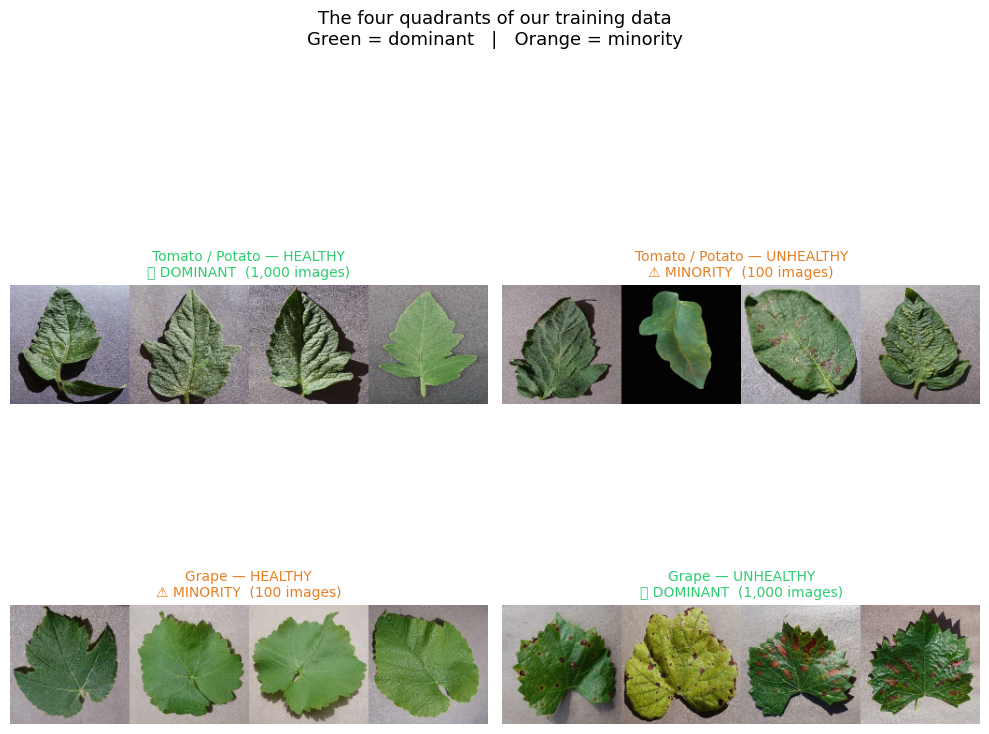

In [ ]:
# Show example images from each quadrant
# Green border = dominant | Orange border = minority

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
fig.suptitle('The four quadrants of our training data\n'
             'Green = dominant   |   Orange = minority',
             fontsize=13, y=1.02)

quadrant_info = [
    (0, 0, 'Tomato / Potato — HEALTHY',   ds_tp_healthy,   True,  n_tp_h),
    (0, 1, 'Tomato / Potato — UNHEALTHY', ds_tp_unhealthy, False, n_tp_u),
    (1, 0, 'Grape — HEALTHY',             ds_gr_healthy,   False, n_gr_h),
    (1, 1, 'Grape — UNHEALTHY',           ds_gr_unhealthy, True,  n_gr_u),
]

for (row, col, title, ds_q, dominant, n) in quadrant_info:
    ax = axes[row, col]
    imgs = [img.numpy() for img, _ in ds_q.take(4)]
    strip = np.concatenate(imgs, axis=1) if imgs else np.zeros((IMG_SIZE, IMG_SIZE*4, 3))
    ax.imshow(np.clip(strip, 0, 1))

    color = '#2ecc71' if dominant else '#e67e22'
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(6)

    status = '✅ DOMINANT' if dominant else '⚠️ MINORITY'
    ax.set_title(f'{title}\n{status}  ({n:,} images)', fontsize=10, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()


> **Question 2:**
> Look at the images in the four quadrants.
> 1. How visually different are grape leaves from tomato and potato leaves?
> 2. Could a model tell the quadrants apart using *only* leaf shape,
>    without looking at any disease symptoms at all?
> 3. Given the class imbalance, what do you expect the model to learn?


---
## Section 2 – Train the model

We train a standard CNN — the same architecture used in Parts 1.


In [ ]:
n_train = int(n_total * 0.8)
X_train, y_train = X[:n_train], y[:n_train]
X_val,   y_val   = X[n_train:], y[n_train:]

# Class weights: up-weight the minority class
w0 = n_total / (2 * n_healthy)
w1 = n_total / (2 * n_unhealthy)
class_weight = {0: w0, 1: w1}

print(f'Training images  : {n_train:,}')
print(f'Validation images: {len(X_val):,}')
print(f'Class weights    -> healthy: {w0:.2f}, unhealthy: {w1:.2f}')


Training images  : 2,880
Validation images: 720
Class weights    -> healthy: 1.00, unhealthy: 1.00


In [ ]:
model_biased = build_cnn()

model_biased.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

print('Training the model...')
history = model_biased.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=30,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1,
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the model...
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8122 - loss: 0.4173 - val_accuracy: 0.9056 - val_loss: 0.3041
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9340 - loss: 0.1824 - val_accuracy: 0.9375 - val_loss: 0.1841
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9559 - loss: 0.1333 - val_accuracy: 0.9431 - val_loss: 0.1687
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9646 - loss: 0.1082 - val_accuracy: 0.9514 - val_loss: 0.1209
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9681 - loss: 0.1014 - val_accuracy: 0.9569 - val_loss: 0.1326
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9646 - loss: 0.0971 - val_accuracy: 0.9611 - val_loss: 0.1499
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9757 - loss: 0.0726 - val_accuracy: 0.9514 - val_loss: 0.1677
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9802 - loss: 0.0549 - va

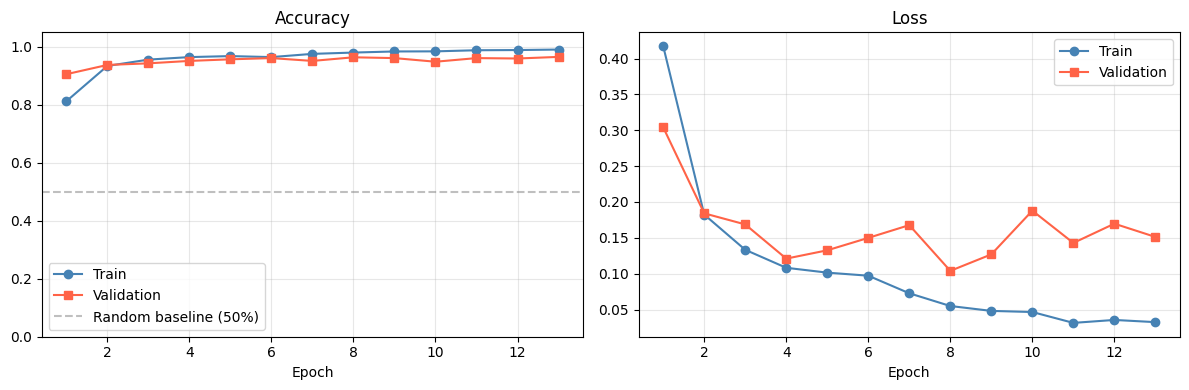

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs, history.history['accuracy'],     'o-', color='steelblue', label='Train')
ax1.plot(epochs, history.history['val_accuracy'], 's-', color='tomato',    label='Validation')
ax1.axhline(0.5, color='grey', linestyle='--', alpha=0.5, label='Random baseline (50%)')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.set_ylim(0, 1.05); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history.history['loss'],     'o-', color='steelblue', label='Train')
ax2.plot(epochs, history.history['val_loss'], 's-', color='tomato',    label='Validation')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Section 3 – Evaluate on the validation set

The validation set comes from the same biased distribution as training.
Grapes are mostly unhealthy; tomato/potato are mostly healthy.
Let's see how well the model does.



Model — validation set
Accuracy: 96.4%

              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.96       355
   Unhealthy       0.97      0.96      0.96       365

    accuracy                           0.96       720
   macro avg       0.96      0.96      0.96       720
weighted avg       0.96      0.96      0.96       720



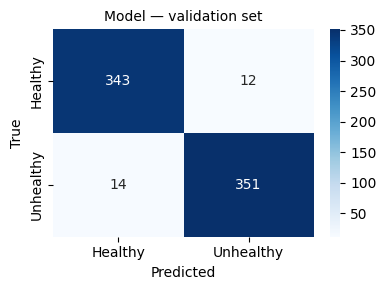

In [ ]:
evaluate(model_biased, X_val, y_val, title='Model — validation set')


> **Question 3:**
> 1. What accuracy did the model achieve on the validation set?
> 2. Does this mean the model has learned to detect plant disease?
>    Or could it be getting the right answer for the wrong reason?
> 3. If you were a researcher who only ran this evaluation,
>    would you trust this model for deployment? Why or why not?


---
## Section 4 – The fair test: break down results by quadrant

A farmer with a mixed crop starts using your disease detector.
Their fields contain all four combinations.
We now evaluate the model **separately** on each of the four quadrants.

> **Make your prediction before running the next cell:**
>
> |  | Healthy | Unhealthy |
> |--|--|--|
> | **Tomato / Potato** | ___% | ___% |
> | **Grape** | ___% | ___% |


In [ ]:
# Evaluate each quadrant using the full dataset (no cap — we want all available images)
def quadrant_accuracy(model, healthy_indices, all_indices, true_label):
    ds_q = make_ds(healthy_indices, all_indices) \
               .filter(lambda img, lbl: tf.equal(lbl, true_label)) \
               .batch(BATCH_SIZE)
    correct, total = 0, 0
    for images, _ in ds_q:
        preds    = np.argmax(model.predict(images, verbose=0), axis=1)
        correct += int(np.sum(preds == true_label))
        total   += len(preds)
    return (correct / total) if total > 0 else 0.0, total

acc_q1, n_q1 = quadrant_accuracy(model_biased, tp_h_idx, tp_h_idx, true_label=0)
acc_q2, n_q2 = quadrant_accuracy(model_biased, tp_h_idx, tp_u_idx, true_label=1)
acc_q3, n_q3 = quadrant_accuracy(model_biased, gr_h_idx, gr_h_idx, true_label=0)
acc_q4, n_q4 = quadrant_accuracy(model_biased, gr_h_idx, gr_u_idx, true_label=1)

print('Accuracy per quadrant:')
print(f'  Q1  Tomato/Potato — Healthy   : {acc_q1*100:.1f}%  ({n_q1:,} images, dominant)')
print(f'  Q2  Tomato/Potato — Unhealthy : {acc_q2*100:.1f}%  ({n_q2:,} images, minority)')
print(f'  Q3  Grape         — Healthy   : {acc_q3*100:.1f}%  ({n_q3:,} images, minority)')
print(f'  Q4  Grape         — Unhealthy : {acc_q4*100:.1f}%  ({n_q4:,} images, dominant)')


Accuracy per quadrant:
  Q1  Tomato/Potato — Healthy   : 99.5%  (1,743 images, dominant)
  Q2  Tomato/Potato — Unhealthy : 70.2%  (18,568 images, minority)
  Q3  Grape         — Healthy   : 92.9%  (423 images, minority)
  Q4  Grape         — Unhealthy : 99.3%  (3,639 images, dominant)


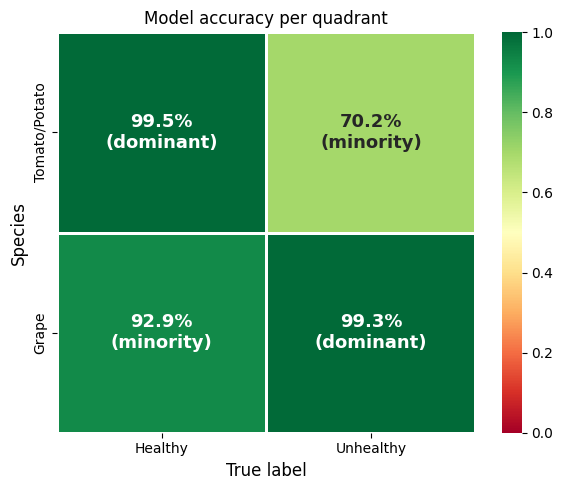

In [ ]:
results = np.array([[acc_q1, acc_q2],
                    [acc_q3, acc_q4]])

annot = np.array([
    [f'{acc_q1*100:.1f}%\n(dominant)', f'{acc_q2*100:.1f}%\n(minority)'],
    [f'{acc_q3*100:.1f}%\n(minority)', f'{acc_q4*100:.1f}%\n(dominant)'],
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(results, annot=annot, fmt='', cmap='RdYlGn',
            vmin=0, vmax=1,
            xticklabels=['Healthy', 'Unhealthy'],
            yticklabels=['Tomato/Potato', 'Grape'],
            ax=ax, linewidths=2, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_xlabel('True label', fontsize=12)
ax.set_ylabel('Species', fontsize=12)
ax.set_title('Model accuracy per quadrant', fontsize=12)
plt.tight_layout()
plt.show()


---

## 🔴 What just happened?

Look at the accuracy table:

- The model performs **well on the dominant quadrants** (many training images)
- The model performs **(more) poorly on the minority quadrants** (few training images)

Specifically:
- **Unhealthy tomato/potato** → often predicted as *healthy*
- **Healthy grape** → often predicted as *unhealthy*

*Being a grape* is strongly linked to *being unhealthy*, and *being a tomato/potato* is strongly linked to *being healthy*.
The model partly learned this association instead of learning actual disease symptoms.

> **Question 4 — the key question:**
> 1. Is this the model's fault? Is it the CNN architecture's fault?
>    Or is it something else entirely?
> 2. What would a better dataset look like?

